In [96]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler


In [98]:
# # Load dataset from Kaggle environment
# df = pd.read_csv('/kaggle/input/the-meta-corpus-of-datasets-the-reddit-dataset/Reddit_Data.csv')

# # Preview
# df.head()

posts = pd.read_csv('C:\\Users\\krish\\OneDrive\\Desktop\\RedditTrendPredictor\\data\\the-reddit-dataset-dataset-posts.csv')
comments = pd.read_csv('C:\\Users\\krish\\OneDrive\\Desktop\\RedditTrendPredictor\\data\\the-reddit-dataset-dataset-comments.csv')

print("Posts shape:", posts.shape)
print("Comments shape:", comments.shape)

posts.head()
comments.head()

Posts shape: (20292, 13)
Comments shape: (54851, 11)


,index,type,id,subreddit.id,subreddit.name,subreddit.nsfw,created_utc,permalink,body,sentiment,score
0,0,comment,hyyz6g8,2r97t,datasets,False,1.646174e+09,https://old.reddit.com/r/datasets/comments/t45...,Spatial problem: Suitability of new locations ...,0.0772,1.0
1,1,comment,hyyid7v,2r97t,datasets,False,1.646167e+09,https://old.reddit.com/r/datasets/comments/sg9...,Have you tried toying around with GDELT or Ali...,0.0000,2.0
2,2,comment,hyxp1qp,2r97t,datasets,False,1.646156e+09,https://old.reddit.com/r/datasets/comments/t44...,Damn random internet person of whom I know not...,-0.3851,3.0
3,3,comment,hyxgnyu,2r97t,datasets,False,1.646153e+09,https://old.reddit.com/r/datasets/comments/t44...,Ah nice one. Best of luck with the baby. If yo...,0.9136,3.0
4,4,comment,hyxfjw6,2r97t,datasets,False,1.646152e+09,https://old.reddit.com/r/datasets/comments/t49...,I was about to write and say this shouldn't be...,0.0762,2.0


In [99]:
# Remove duplicates
posts.drop_duplicates(inplace=True)
comments.drop_duplicates(inplace=True)

# Handle missing data
posts.fillna({'selftext': '', 'title': ''}, inplace=True)
comments.fillna({'body': ''}, inplace=True)


In [100]:
!pip install textblob
from textblob import TextBlob



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [101]:
# Convert created_utc to datetime
posts['created_utc'] = pd.to_datetime(posts['created_utc'], errors='coerce')

# Extract useful time-based features
posts['hour'] = posts['created_utc'].dt.hour
posts['dayofweek'] = posts['created_utc'].dt.dayofweek
posts['month'] = posts['created_utc'].dt.month

# Text-based features
posts['title_len'] = posts['title'].apply(lambda x: len(str(x)))
posts['selftext_len'] = posts['selftext'].apply(lambda x: len(str(x)))

# Sentiment (optional but improves accuracy)
posts['sentiment'] = posts['title'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)


In [102]:
comments.columns
posts.columns

Index(['index', 'type', 'id', 'subreddit.id', 'subreddit.name',
       'subreddit.nsfw', 'created_utc', 'permalink', 'domain', 'url',
       'selftext', 'title', 'score', 'hour', 'dayofweek', 'month', 'title_len',
       'selftext_len', 'sentiment'],
      dtype='object')

In [103]:
# Remove stray spaces in column names
comments.columns = comments.columns.str.strip()
posts.columns = posts.columns.str.strip()

# Ensure numeric types for sentiment and score
comments['sentiment'] = pd.to_numeric(comments['sentiment'], errors='coerce').fillna(0)
comments['score'] = pd.to_numeric(comments['score'], errors='coerce').fillna(0)


In [104]:
comment_stats = comments.groupby('subreddit.name').agg(
    num_comments=('id', 'count'),
    avg_comment_sentiment=('sentiment', 'mean'),
    avg_comment_score=('score', 'mean')
).reset_index()

comment_stats.head()


,subreddit.name,num_comments,avg_comment_sentiment,avg_comment_score
0,datasets,54848,0.256304,2.019271


In [105]:
posts = posts.merge(
    comment_stats,
    how='left',
    left_on='subreddit.name',
    right_on='subreddit.name'
)


In [106]:
comment_stats.columns
comment_stats.head()


,subreddit.name,num_comments,avg_comment_sentiment,avg_comment_score
0,datasets,54848,0.256304,2.019271


In [107]:
posts['num_comments'] = posts['num_comments'].fillna(0)
posts['avg_comment_sentiment'] = posts['avg_comment_sentiment'].fillna(0)
posts['avg_comment_score'] = posts['avg_comment_score'].fillna(0)


In [108]:
posts[['subreddit.name', 'num_comments', 'avg_comment_sentiment', 'avg_comment_score']].head()


,subreddit.name,num_comments,avg_comment_sentiment,avg_comment_score
0,datasets,54848,0.256304,2.019271
1,datasets,54848,0.256304,2.019271
2,datasets,54848,0.256304,2.019271
3,datasets,54848,0.256304,2.019271
4,datasets,54848,0.256304,2.019271


In [109]:
# Define threshold as 90th percentile of post score
threshold = posts['score'].quantile(0.90)

# Binary label: 1 if trending, else 0
posts['is_trending'] = (posts['score'] >= threshold).astype(int)

# Check class balance
posts['is_trending'].value_counts(normalize=True)


is_trending
0    0.898285
1    0.101715
Name: proportion, dtype: float64

In [110]:
features = [
    'title_len', 'selftext_len', 'hour', 'dayofweek', 'month',
    'sentiment', 'num_comments', 'avg_comment_sentiment', 'avg_comment_score'
]

X = posts[features].fillna(0)
y = posts['is_trending']


In [111]:
# --- Combine title + selftext into a single text column ---
posts['text'] = (posts['title'].fillna('') + ' ' + posts['selftext'].fillna('')).str.lower()

# --- Prepare numeric and text features ---
numeric_features = [
    'title_len', 'selftext_len', 'hour', 'dayofweek', 'month',
    'sentiment', 'num_comments', 'avg_comment_sentiment', 'avg_comment_score'
]

X_numeric = posts[numeric_features].fillna(0)
y = posts['is_trending']

# --- TF-IDF on combined text ---
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
X_tfidf = tfidf.fit_transform(posts['text'])

# --- Combine TF-IDF and numeric features ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)  # with_mean=False because sparse matrix
X_scaled_numeric = scaler.fit_transform(X_numeric)

from scipy.sparse import csr_matrix
X_full = hstack([csr_matrix(X_scaled_numeric), X_tfidf])


In [112]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [113]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [114]:
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train_scaled, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [115]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=42
)

clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.90      0.99      0.95      3646
           1       0.44      0.07      0.12       413

    accuracy                           0.90      4059
   macro avg       0.67      0.53      0.53      4059
weighted avg       0.86      0.90      0.86      4059

ROC-AUC: 0.7705077307846072


In [116]:
import joblib
joblib.dump(clf, "../models/trend_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
print("✅ Saved model, vectorizer, and scaler.")


✅ Saved model, vectorizer, and scaler.


In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

feat_imp = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance — Reddit Trend Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

feat_imp


ValueError: Length of values (1009) does not match length of index (9)

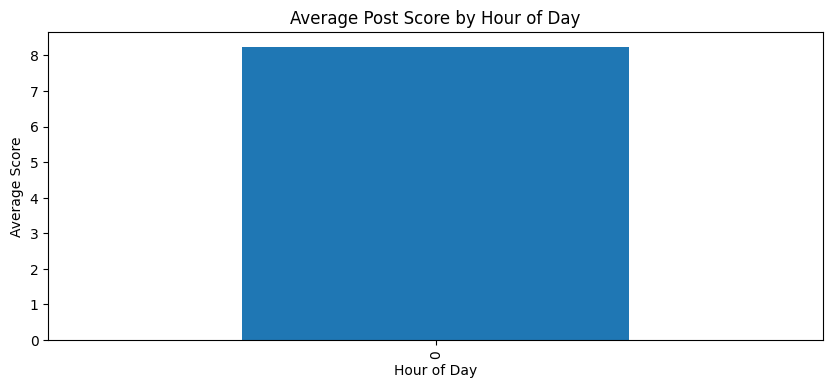

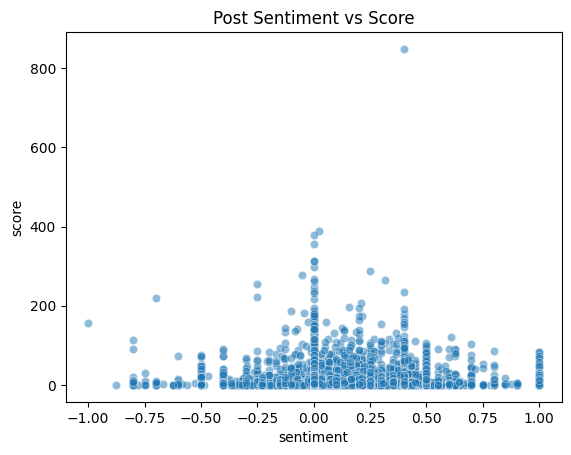

In [ ]:
# Average post score by hour
posts.groupby('hour')['score'].mean().plot(kind='bar', figsize=(10,4))
plt.title("Average Post Score by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Score")
plt.show()

# Average sentiment vs score
sns.scatterplot(x='sentiment', y='score', data=posts, alpha=0.5)
plt.title("Post Sentiment vs Score")
plt.show()


# “what” topics make them trend.

In [ ]:
!pip install wordcloud



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from wordcloud import WordCloud
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\krish\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [ ]:
# Combine title and body text
posts['text'] = (posts['title'].fillna('') + ' ' + posts['selftext'].fillna('')).str.lower()

# Remove rows with empty text
posts = posts[posts['text'].str.strip() != '']

# Define stopwords
stop_words = stopwords.words('english')


In [ ]:
tfidf = TfidfVectorizer(
    max_features=500,
    stop_words=stop_words,
    ngram_range=(1,2)   # include unigrams and bigrams
)

X_tfidf = tfidf.fit_transform(posts['text'])


In [ ]:
svd = TruncatedSVD(n_components=10, random_state=42)
X_topics = svd.fit_transform(X_tfidf)

# Add topic features to dataframe
for i in range(10):
    posts[f'topic_{i+1}'] = X_topics[:, i]


In [ ]:
features = [
    'title_len', 'selftext_len', 'hour', 'dayofweek', 'month',
    'sentiment', 'num_comments', 'avg_comment_sentiment', 'avg_comment_score'
] + [f'topic_{i+1}' for i in range(10)]

X = posts[features].fillna(0)
y = posts['is_trending']


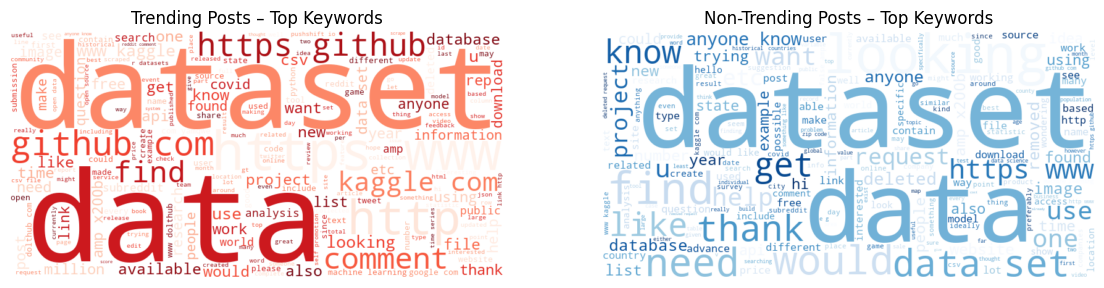

In [ ]:
from collections import Counter

# Separate trending & non-trending posts
trending_text = ' '.join(posts.loc[posts['is_trending']==1, 'text'])
normal_text   = ' '.join(posts.loc[posts['is_trending']==0, 'text'])

# Generate word clouds
wc_trending = WordCloud(width=800, height=400, background_color='white',
                        stopwords=stop_words, colormap='Reds').generate(trending_text)
wc_normal = WordCloud(width=800, height=400, background_color='white',
                      stopwords=stop_words, colormap='Blues').generate(normal_text)

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(wc_trending, interpolation='bilinear')
plt.axis('off')
plt.title("Trending Posts – Top Keywords")

plt.subplot(1,2,2)
plt.imshow(wc_normal, interpolation='bilinear')
plt.axis('off')
plt.title("Non-Trending Posts – Top Keywords")
plt.show()


In [ ]:
terms = tfidf.get_feature_names_out()
for i, comp in enumerate(svd.components_):
    terms_in_topic = [terms[idx] for idx in comp.argsort()[-10:]]
    print(f"Topic {i+1}: {', '.join(terms_in_topic)}")


Topic 1: anyone, would, find, request, datasets, looking, removed, deleted, dataset, data
Topic 2: false amp, test, words, reviews, request dataset, user, full, dataset, request, deleted
Topic 3: need dataset, survey, image, user, images, looking dataset, request dataset, request, dataset, removed
Topic 4: know, find, would, https, anyone, images, datasets, looking dataset, looking, dataset
Topic 5: know, machine learning, machine, free, learning, removed, deleted, find, looking datasets, datasets
Topic 6: github com, github, www kaggle, kaggle com, kaggle, amp, https www, www, com, https
Topic 7: set, like, looking, find, know, anyone, database, us, would, request
Topic 8: list, historical, open data, us, open, request dataset, dataset, datasets, data, request
Topic 9: kaggle, learning, looking data, https, com, images, datasets, request, data set, set
Topic 10: https www, https, state, hi looking, amp, looking datasets, looking data, us, looking dataset, looking
